## Import Libraries

In [27]:
import os
import numpy as np
import cv2 as cv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


##  3. Dataset Path & Image Count

In [28]:
DATASET_PATH = r"/Users/macbookair/Library/CloudStorage/OneDrive-Personal/pridict_dog_cat/Photo"

print("Dataset contents:")
for folder in sorted(os.listdir(DATASET_PATH)):
    full_path = os.path.join(DATASET_PATH, folder)
    if os.path.isdir(full_path):
        count = len(os.listdir(full_path))
        print(f"  {folder}: {count} images")

Dataset contents:
  Catss: 100 images
  Dog: 100 images


## 4. Load & Preprocess Images

In [29]:
IMG_SIZE = (64, 64)  # Resize all images to 64x64 pixels

def im_to_array(path, size=IMG_SIZE):
    """Read all images in a folder, resize, normalize, and return as numpy array."""
    image_list = []
    if not os.path.exists(path):
        print(f"Folder does not exist: {path}")
        return np.array([])

    files = os.listdir(path)
    print(f"Reading {len(files)} files from: {path}")

    for filename in files:
        img_path = os.path.join(path, filename)
        img = cv.imread(img_path)
        if img is None:
            print(f"  [Skip] Cannot read: {filename}")
            continue
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # OpenCV reads BGR -> convert to RGB
        img = cv.resize(img, size)
        img = img / 255.0                         # Normalize pixel values to [0, 1]
        image_list.append(img)

    print(f"  Successfully loaded: {len(image_list)} images")
    return np.array(image_list)

# Load both classes
im_cat = im_to_array(os.path.join(DATASET_PATH, 'Catss'))
y_cat  = np.ones(im_cat.shape[0],  dtype=np.int64)  # Label 1 = Cat

im_dog = im_to_array(os.path.join(DATASET_PATH, 'Dog'))
y_dog  = np.zeros(im_dog.shape[0], dtype=np.int64)  # Label 0 = Dog

# Combine datasets
X = np.concatenate((im_cat, im_dog), axis=0)  # shape: (N, 64, 64, 3)
y = np.concatenate((y_cat,  y_dog),  axis=0)

print(f"\nCombined dataset   -- X: {X.shape}, y: {y.shape}")
print(f"Class distribution -- Dog: {np.sum(y==0)}, Cat: {np.sum(y==1)}")

Reading 100 files from: /Users/macbookair/Library/CloudStorage/OneDrive-Personal/pridict_dog_cat/Photo/Catss
  Successfully loaded: 100 images
Reading 100 files from: /Users/macbookair/Library/CloudStorage/OneDrive-Personal/pridict_dog_cat/Photo/Dog
  Successfully loaded: 100 images

Combined dataset   -- X: (200, 64, 64, 3), y: (200,)
Class distribution -- Dog: 100, Cat: 100


### 4.1 Visualize Sample Images

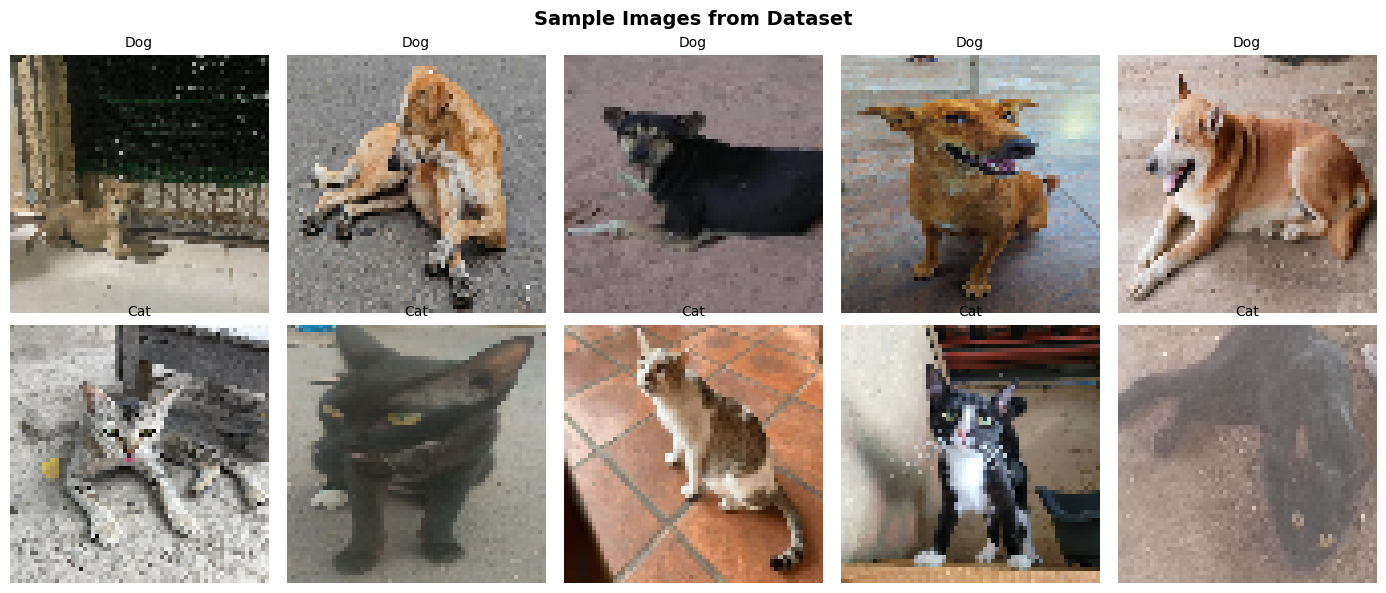

In [30]:
class_names = {0: 'Dog', 1: 'Cat'}

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Images from Dataset', fontsize=14, fontweight='bold')

for i in range(5):
    axes[0, i].imshow(im_dog[i])
    axes[0, i].set_title('Dog', fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(im_cat[i])
    axes[1, i].set_title('Cat', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 5. Flatten Images for ANN Input

An ANN (fully-connected network) takes a **1D vector** as input, not a 2D/3D image.  
Each image of shape (64, 64, 3) is flattened into a vector of **64 x 64 x 3 = 12,288 features**.

In [31]:
N = X.shape[0]
X_flat = X.reshape(N, -1)        # (N, 64*64*3) = (N, 12288)

print(f"Original image shape : {X.shape}")
print(f"Flattened shape      : {X_flat.shape}")

INPUT_SIZE = X_flat.shape[1]     # 12288
print(f"ANN input size       : {INPUT_SIZE} features per image")

Original image shape : (200, 64, 64, 3)
Flattened shape      : (200, 12288)
ANN input size       : 12288 features per image


## 6. Train / Test Split

> **Important**: The test set is held out completely and is **never used during training**.  
> It is only used once at the end for final evaluation.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

print(f"Train set -- X: {X_train.shape}, y: {y_train.shape}")
print(f"Test  set -- X: {X_test.shape},  y: {y_test.shape}")
print(f"\nTrain class dist -- Dog: {np.sum(y_train==0)}, Cat: {np.sum(y_train==1)}")
print(f"Test  class dist -- Dog: {np.sum(y_test==0)},  Cat: {np.sum(y_test==1)}")


Train set -- X: (160, 12288), y: (160,)
Test  set -- X: (40, 12288),  y: (40,)

Train class dist -- Dog: 80, Cat: 80
Test  class dist -- Dog: 20,  Cat: 20


## 7. Convert to PyTorch Tensors & DataLoaders

In [33]:
# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"X_test_tensor  shape: {X_test_tensor.shape}")

# Create TensorDataset and DataLoader
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatch size    : {BATCH_SIZE}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

X_train_tensor shape: torch.Size([160, 12288])
X_test_tensor  shape: torch.Size([40, 12288])

Batch size    : 32
Train batches : 5
Test  batches : 2


## 8. Define the ANN Model

Architecture (fully-connected layers only — no convolution):

```
Input  (12288)
  |-- Linear(12288 -> 512) -> ReLU -> Dropout(0.3)
       |-- Linear(512 -> 256) -> ReLU -> Dropout(0.3)
            |-- Linear(256 -> 128) -> ReLU
                 |-- Linear(128 -> 2)    <-- output logits
```

In [34]:
class my_ANN(nn.Module):
    def __init__(self, input_size):
        super(my_ANN, self).__init__()

        # Layer 1: input -> hidden1
        self.fc1   = nn.Linear(input_size, 512)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)

        # Layer 2: hidden1 -> hidden2
        self.fc2   = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)

        # Layer 3: hidden2 -> hidden3
        self.fc3   = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()

        # Output layer: hidden3 -> 2 classes (Dog=0, Cat=1)
        self.fc4   = nn.Linear(128, 2)

    def forward(self, x):
        # x shape: (batch_size, 12288)  -- already flat
        x = self.drop1(self.relu1(self.fc1(x)))   # Layer 1
        x = self.drop2(self.relu2(self.fc2(x)))   # Layer 2
        x = self.relu3(self.fc3(x))               # Layer 3
        x = self.fc4(x)                           # Output logits
        return x

# Instantiate and move to device
model = my_ANN(input_size=INPUT_SIZE).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

my_ANN(
  (fc1): Linear(in_features=12288, out_features=512, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=128, out_features=2, bias=True)
)

Total trainable parameters: 6,456,450


## 9. Loss Function & Optimizer

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss     : CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001) - Faster convergence than SGD")

AttributeError: partially initialized module 'torch._dynamo' has no attribute 'config' (most likely due to a circular import)

## 10. Training Loop

> Train and val loss/accuracy are tracked every epoch.  
> The best model (lowest val loss) is saved automatically to Google Drive.

In [ ]:
EPOCHS = 60
MODEL_SAVE_PATH = "best_ann_model.pth"

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_loss = float('inf')
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 55)

for epoch in range(EPOCHS):

    # ---- Training Phase -----------------------------------------------
    model.train()
    train_loss    = 0.0
    train_correct = 0
    train_total   = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()            # Clear previous gradients
        outputs = model(inputs)          # Forward pass
        loss = criterion(outputs, labels)
        loss.backward()                  # Backpropagation
        optimizer.step()                 # Update weights

        train_loss    += loss.item() * inputs.size(0)
        _, predicted   = torch.max(outputs, 1)
        train_total   += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss / train_total
    avg_train_acc  = train_correct / train_total * 100

    # ---- Validation Phase (READ ONLY -- no weight updates) ------------
    model.eval()
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total   += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / val_total
    avg_val_acc  = val_correct / val_total * 100

    # Save best model checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        saved_marker = " * saved"
    else:
        saved_marker = ""

    # Record history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)

    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:>6} | {avg_train_loss:>10.4f} | {avg_train_acc:>8.2f}% | "
              f"{avg_val_loss:>8.4f} | {avg_val_acc:>7.2f}%{saved_marker}")

print("\nTraining complete!")
print(f"Best model saved at: {MODEL_SAVE_PATH}")

 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
     1 |     0.4198 |    81.88% |   1.1599 |   50.00% * saved
     5 |     0.4818 |    83.12% |   0.6778 |   55.00%
    10 |     0.3972 |    82.50% |   0.9077 |   57.50%
    15 |     0.4226 |    78.12% |   0.8171 |   52.50%
    20 |     0.3078 |    90.62% |   0.8360 |   57.50%
    25 |     0.5916 |    65.00% |   0.6674 |   60.00%
    30 |     0.3703 |    85.00% |   0.7250 |   62.50%
    35 |     0.4940 |    76.88% |   0.7193 |   65.00%
    40 |     0.2398 |    94.38% |   0.8697 |   65.00%
    45 |     0.5377 |    71.25% |   0.6744 |   55.00%
    50 |     0.4540 |    78.75% |   0.6750 |   65.00%
    55 |     0.9068 |    54.37% |   0.7382 |   50.00%
    60 |     0.6876 |    53.75% |   0.6917 |   55.00%

Training complete!
Best model saved at: best_ann_model.pth


## 11. Training Curves


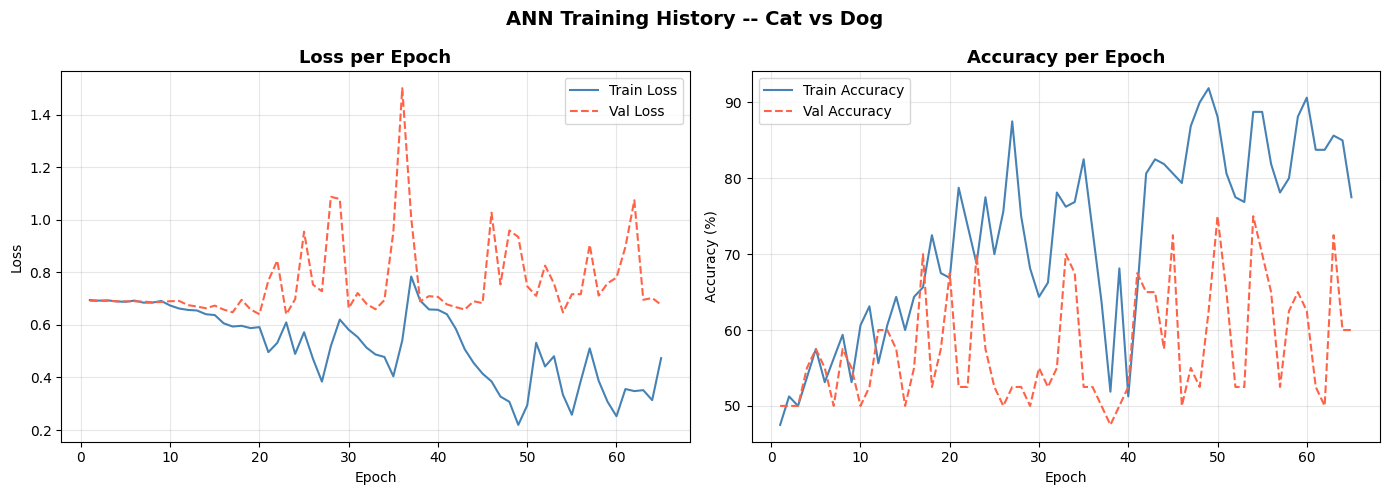

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

# Loss curve
ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato', linestyle='--')
ax1.set_title('Loss per Epoch', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy curve
ax2.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='steelblue')
ax2.plot(epochs_range, history['val_acc'],   label='Val Accuracy',   color='tomato', linestyle='--')
ax2.set_title('Accuracy per Epoch', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('ANN Training History -- Cat vs Dog', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Final Evaluation on Test Set

> Load the **best saved model** and evaluate on the held-out test set (used only here).

In [ ]:
# Load best model weights
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("=" * 48)
print("         FINAL TEST SET EVALUATION")
print("=" * 48)
print(f"  Test Accuracy : {acc * 100:.2f}%")
print()

         FINAL TEST SET EVALUATION
  Test Accuracy : 70.00%



### 12.1 Confusion Matrix

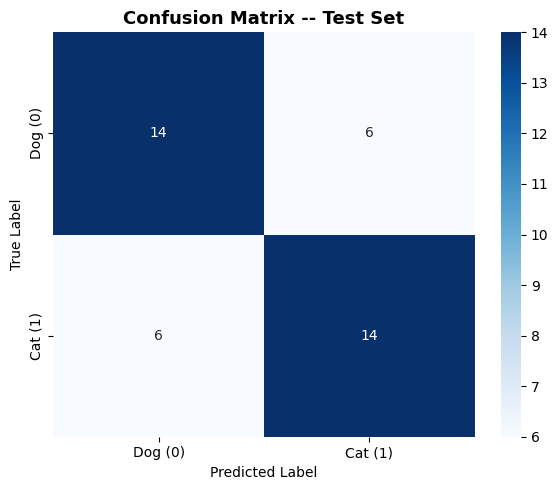

True  Dog (TN): 14  |  False Cat (FP): 6
False Dog (FN): 6  |  True  Cat (TP): 14


In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dog (0)', 'Cat (1)'],
            yticklabels=['Dog (0)', 'Cat (1)'],
            ax=ax)
ax.set_title('Confusion Matrix -- Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

print(f"True  Dog (TN): {cm[0,0]}  |  False Cat (FP): {cm[0,1]}")
print(f"False Dog (FN): {cm[1,0]}  |  True  Cat (TP): {cm[1,1]}")

### 12.2 Classification Report

In [ ]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Dog (0)', 'Cat (1)']))

Classification Report:
              precision    recall  f1-score   support

     Dog (0)       0.70      0.70      0.70        20
     Cat (1)       0.70      0.70      0.70        20

    accuracy                           0.70        40
   macro avg       0.70      0.70      0.70        40
weighted avg       0.70      0.70      0.70        40



### 12.3 Visualize Predictions

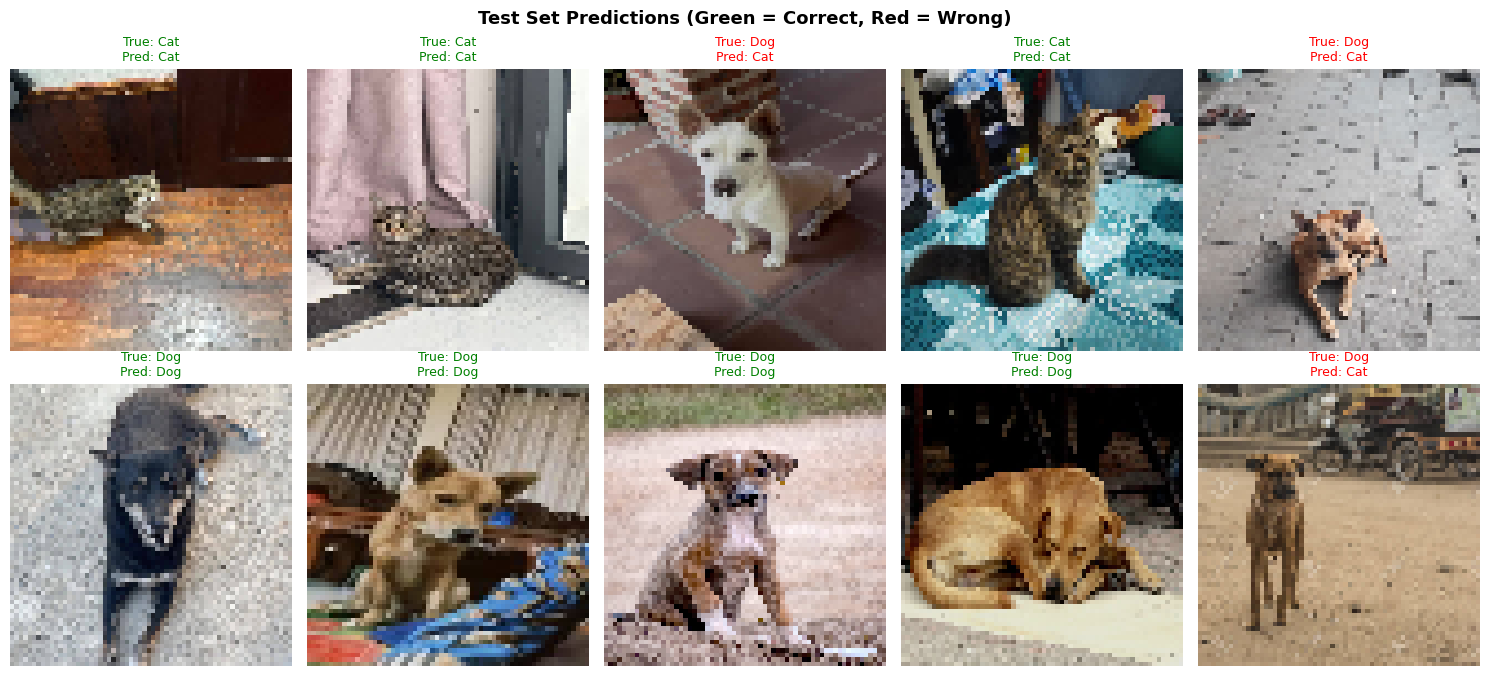

In [ ]:
# Recover original (unflattened) test images for display only
X_test_images = X_test.reshape(-1, 64, 64, 3)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Test Set Predictions (Green = Correct, Red = Wrong)', fontsize=13, fontweight='bold')

sample_idx = np.random.choice(len(y_true), size=10, replace=False)

for i, idx in enumerate(sample_idx):
    ax = axes[i // 5][i % 5]
    img        = X_test_images[idx]
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    correct    = (y_true[idx] == y_pred[idx])

    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}",
                 color='green' if correct else 'red', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 13. Predict a Single New Image

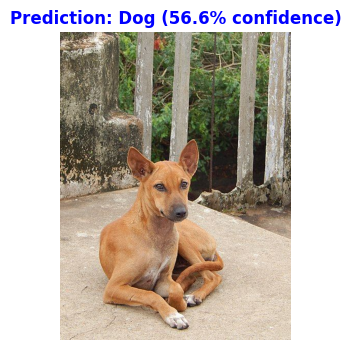

Dog probability : 56.6%
Cat probability : 43.4%


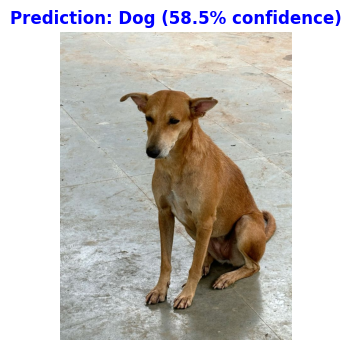

Dog probability : 58.5%
Cat probability : 41.5%


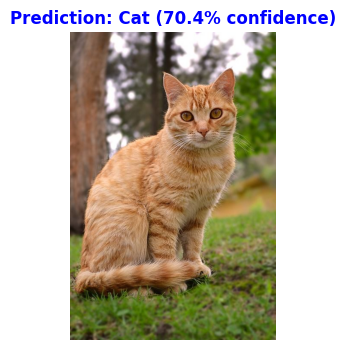

Dog probability : 29.6%
Cat probability : 70.4%


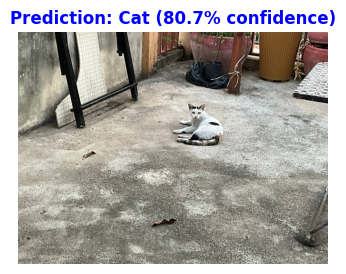

Dog probability : 19.3%
Cat probability : 80.7%


In [ ]:
def predict_image(image_path, model, device, size=IMG_SIZE):
    """Predict the class (Dog/Cat) of a single image file using the ANN."""
    img = cv.imread(image_path)
    if img is None:
        print(f"Cannot read image: {image_path}")
        return

    img_rgb     = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_resized = cv.resize(img_rgb, size)
    img_norm    = img_resized / 255.0

    # Flatten: (64, 64, 3) -> (1, 12288)
    img_flat = img_norm.reshape(1, -1)
    tensor   = torch.tensor(img_flat, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        output        = model(tensor)
        probabilities = torch.softmax(output, dim=1)[0]
        pred_class    = torch.argmax(probabilities).item()

    label      = class_names[pred_class]
    confidence = probabilities[pred_class].item() * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {label} ({confidence:.1f}% confidence)",
              fontsize=12, fontweight='bold', color='blue')
    plt.axis('off')
    plt.show()
    print(f"Dog probability : {probabilities[0].item()*100:.1f}%")
    print(f"Cat probability : {probabilities[1].item()*100:.1f}%")

# Example usage (uncomment and set your own image path):
predict_image('C:\\Users\\ASUS VIVOBOOK\\Documents\\year3_semester2\\IML\\project4\\test1.jpg', model, device)
predict_image('C:\\Users\\ASUS VIVOBOOK\\Documents\\year3_semester2\\IML\\project4\\test2.jpg', model, device)
predict_image('C:\\Users\\ASUS VIVOBOOK\\Documents\\year3_semester2\\IML\\project4\\test3.jpg', model, device)
predict_image('C:\\Users\\ASUS VIVOBOOK\\Documents\\year3_semester2\\IML\\project4\\test4.jpg', model, device )


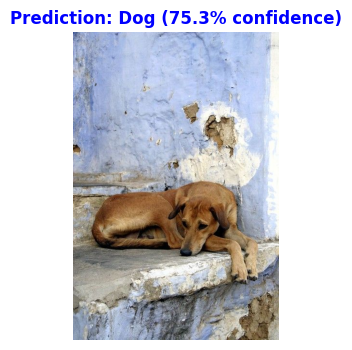

Dog probability : 75.3%
Cat probability : 24.7%


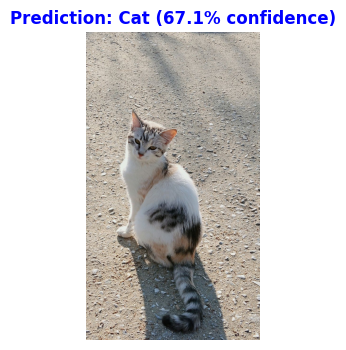

Dog probability : 32.9%
Cat probability : 67.1%


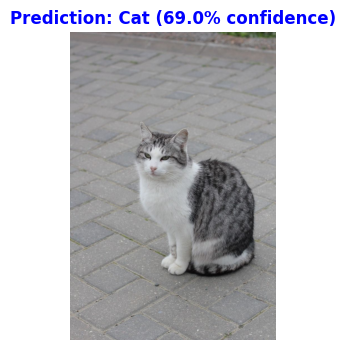

Dog probability : 31.0%
Cat probability : 69.0%


In [ ]:
predict_image('C:\\Users\\ASUS VIVOBOOK\\Documents\\year3_semester2\\IML\\project4\\test5.jpg',model, device)
predict_image('C:\\Users\\ASUS VIVOBOOK\\Documents\\year3_semester2\\IML\\project4\\test6.jpg',model, device)
predict_image('C:\\Users\\ASUS VIVOBOOK\\Documents\\year3_semester2\\IML\\project4\\test7.jpg',model, device)


In [ ]:
# Save final model state (in addition to the best checkpoint saved during training)
MODEL_SAVE_PATH = "best_ann_model.pth"
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"✅ Model saved to: {MODEL_SAVE_PATH}")


✅ Model saved to: best_ann_model.pth
